In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Paths to your files
file1 = r"C:/datasources/corpus_file_list_by_size.txt"
file2 = r"C:/datasources/blackvault_corpus_file_list_by_size.txt"

# Load as dataframes
df1 = pd.read_csv(file1, sep=" ", names=["size", "filename"], engine="python")
df2 = pd.read_csv(file2, sep=" ", names=["size", "filename"], engine="python")

# Sort by size (largest first)
df1_sorted = df1.sort_values(by="size", ascending=False)
df2_sorted = df2.sort_values(by="size", ascending=False)

# Remove smallest files

df1 = df1[df1["size"] >= 650].copy()
df2 = df2[df2["size"] >= 650].copy()

# Define substrings to remove
heavy_patterns = ["s3.documentcloud", "files.usrtk", "wp-content_uploads"]

# Build regex pattern (joined with | means "OR")
pattern = "|".join(heavy_patterns)

# Filter both dataframes
df1 = df1[~df1["filename"].str.contains(pattern, na=False)].copy()
df2 = df2[~df2["filename"].str.contains(pattern, na=False)].copy()

# Cut pdfs from black vault
df2 = df2[~df2["filename"].str.contains("pdf", na=False)].copy()

total_size_df1 = df1["size"].sum()
total_size_df2 = df2["size"].sum()

print("Total size of df1:", total_size_df1)
print("Total size of df2:", total_size_df2)

Total size of df1: 1913759473.0
Total size of df2: 145435276.0


In [9]:
# Sort df1 and save
df1_sorted = df1.sort_values(by="size", ascending=False)
df1_sorted.to_csv("C:/datasources/corpus_main_list.txt", sep=" ", index=False, header=False)

# Sort df2 and save
df2_sorted = df2.sort_values(by="size", ascending=False)
df2_sorted.to_csv("C:/datasources/corpus_blackvault_list.txt", sep=" ", index=False, header=False)

In [10]:
dfscrub = pd.read_csv("C:/datasources/corpus_main_list.txt", sep=" ", names=["size", "filename"], engine="python")
total_size_scrub = dfscrub["size"].sum()

print("Total size of df1:", total_size_scrub)

Total size of df1: 1575190731.0


In [2]:
# Jupyter cell: corpus cleaner
# 1) If needed, install deps right in the notebook:
# %pip install beautifulsoup4 lxml ftfy chardet tqdm

import os, re, csv, shutil, html, unicodedata
from pathlib import Path
from bs4 import BeautifulSoup
from ftfy import fix_text
import chardet
from tqdm import tqdm

# --- CONFIG ---
INPUT_DIR  = Path("C:/datasources/ai_corpus_slimmer/corpus_beta_set_slim")   # <- change me
OUTPUT_DIR = Path("C:/datasources/ai_corpus_slimmer/ai_corpus_slimmer_clean")  # <- change me
REJECT_DIR = OUTPUT_DIR / "rejected"
LOG_CSV    = OUTPUT_DIR / "clean_log.csv"
EXTS       = {".txt", ".html", ".htm"}
WORDS_IN_A_ROW_THRESHOLD = 60
ALPHA_TOKEN_MIN_FRACTION = 0.80   # in a 100-word window, ≥80% tokens should be alphabetic
MAX_NONASCII_FRACTION    = 0.20   # in a 100-word window, ≤20% chars non-ASCII
DRY_RUN = False  # True = do not write/move; just report

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REJECT_DIR.mkdir(parents=True, exist_ok=True)

def read_text_with_detection(p: Path) -> str:
    raw = p.read_bytes()
    guess = chardet.detect(raw) or {}
    enc = guess.get("encoding") or "utf-8"
    try:
        return raw.decode(enc, errors="replace")
    except LookupError:
        return raw.decode("utf-8", errors="replace")

def strip_html(text: str, ext: str) -> str:
    # Heuristic: if looks like HTML or extension is html/htm -> parse
    looks_like_html = ("<html" in text[:1000].lower()) or ("</p>" in text.lower()) or ("<body" in text.lower())
    if ext in {".html", ".htm"} or looks_like_html:
        soup = BeautifulSoup(text, "lxml")  # fallbacks to html.parser if lxml missing
        for tag in soup(["script", "style", "noscript"]):
            tag.decompose()
        text = soup.get_text(separator=" ")
    # Unescape entities
    return html.unescape(text)

def normalize_and_clean(text: str) -> str:
    # Fix mojibake and weird unicode
    text = fix_text(text)
    # Normalize to NFC
    text = unicodedata.normalize("NFC", text)
    # Remove control / non-printing (keep basic whitespace)
    text = "".join(ch if (ch.isprintable() or ch in "\n\t ") else " " for ch in text)
    # Replace intraword punctuation like "securIty^^^>^^" with spaces around runs
    text = re.sub(r"[^\w\s]", " ", text)
    # Collapse runs of underscores/dashes/etc. to a space
    text = re.sub(r"[_\-+=~^`|\\/<>{}\[\]()*#%$@:;.,!?]{2,}", " ", text)
    # Collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text

_word_re = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")  # alpha tokens; allow simple apostrophes

def has_natural_language_run(clean_text: str,
                             window_size: int = WORDS_IN_A_ROW_THRESHOLD,
                             alpha_min_frac: float = ALPHA_TOKEN_MIN_FRACTION,
                             max_nonascii_frac: float = MAX_NONASCII_FRACTION) -> bool:
    # Tokenize to words
    tokens = _word_re.findall(clean_text)
    if len(tokens) < window_size:
        return False

    # Precompute for sliding window: mark alpha-only tokens
    is_alpha = [t.isalpha() for t in tokens]

    # For non-ASCII fraction per window, work on character slices:
    # Make a quick index of cumulative counts to avoid O(n^2).
    chars = clean_text
    # To approximate per-window non-ASCII, we map token indices to char spans.
    # Simpler heuristic: compute on token strings themselves.
    token_nonascii_frac = [sum(ord(c) > 127 for c in t)/max(1,len(t)) for t in tokens]

    # Slide 100-word window
    alpha_count = sum(is_alpha[:window_size])
    nonascii_avg = sum(token_nonascii_frac[:window_size]) / window_size

    if alpha_count / window_size >= alpha_min_frac and nonascii_avg <= max_nonascii_frac:
        return True

    for i in range(window_size, len(tokens)):
        # remove left, add right
        alpha_count += is_alpha[i] - is_alpha[i - window_size]
        nonascii_avg += (token_nonascii_frac[i] - token_nonascii_frac[i - window_size]) / window_size
        if alpha_count / window_size >= alpha_min_frac and nonascii_avg <= max_nonascii_frac:
            return True

    return False

def is_garbled(clean_text: str) -> bool:
    # Reject if too short overall
    if len(clean_text) < 400:  # ~a few sentences
        return True
    # Ratio of letters to all non-space chars; if extremely low, it's junk
    nospace = clean_text.replace(" ", "")
    if not nospace:
        return True
    alpha = sum(c.isalpha() for c in nospace)
    if alpha / len(nospace) < 0.55:
        return True
    return False

def relative_output_path(src: Path) -> Path:
    rel = src.relative_to(INPUT_DIR)
    return OUTPUT_DIR / rel.with_suffix(".txt")  # save everything as clean .txt

files = [p for p in INPUT_DIR.rglob("*") if p.is_file() and p.suffix.lower() in EXTS]

stats = {
    "total_files": len(files),
    "clean_kept": 0,
    "rejected": 0,
}

log_rows = []
pbar = tqdm(files, desc="Cleaning files")
for src in pbar:
    try:
        raw = read_text_with_detection(src)
        stripped = strip_html(raw, src.suffix.lower())
        cleaned = normalize_and_clean(stripped)

        ok_run = has_natural_language_run(cleaned)
        junky  = is_garbled(cleaned)

        decision = "keep" if (ok_run and not junky) else "reject"

        if decision == "keep":
            dst = relative_output_path(src)
            if not DRY_RUN:
                dst.parent.mkdir(parents=True, exist_ok=True)
                with open(dst, "w", encoding="utf-8", newline="\n") as f:
                    f.write(cleaned)
            stats["clean_kept"] += 1
        else:
            # Move original to rejected/ (keep relative path)
            rej = REJECT_DIR / src.relative_to(INPUT_DIR)
            if not DRY_RUN:
                rej.parent.mkdir(parents=True, exist_ok=True)
                shutil.move(str(src), str(rej))
            stats["rejected"] += 1

        log_rows.append({
            "source_path": str(src),
            "decision": decision,
            "clean_chars": len(cleaned),
            "total_words": len(_word_re.findall(cleaned)),
        })

    except Exception as e:
        log_rows.append({
            "source_path": str(src),
            "decision": f"error: {type(e).__name__}: {e}",
            "clean_chars": 0,
            "total_words": 0,
        })

# Write log
if not DRY_RUN:
    LOG_CSV.parent.mkdir(parents=True, exist_ok=True)
    with open(LOG_CSV, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=["source_path","decision","clean_chars","total_words"])
        w.writeheader()
        w.writerows(log_rows)

print("DONE\n", stats)
print(f"Log at: {LOG_CSV}")
print(f"Rejected originals moved under: {REJECT_DIR}")
print(f"Cleaned texts under: {OUTPUT_DIR}")



Cleaning files: 100%|████████████████████████████████████████████████████████████| 12215/12215 [07:09<00:00, 28.42it/s]

DONE
 {'total_files': 12215, 'clean_kept': 12199, 'rejected': 14}
Log at: C:\datasources\ai_corpus_slimmer\ai_corpus_slimmer_clean\clean_log.csv
Rejected originals moved under: C:\datasources\ai_corpus_slimmer\ai_corpus_slimmer_clean\rejected
Cleaned texts under: C:\datasources\ai_corpus_slimmer\ai_corpus_slimmer_clean


In [2]:
# Final indexing of beta slim step 1

from pathlib import Path
import json, re, math
import numpy as np
import pandas as pd

# --- Paths ---
BASE = Path(r"C:/datasources")
ARTICLES_JSON = BASE / "ai" / "articles_df.json"
TEXT_DIR      = BASE / "ai_corpus_slimmer" / "ai_corpus_slimmer_clean"

# --- Load articles JSON ---
try:
    articles_df = pd.read_json(ARTICLES_JSON)
except ValueError:
    articles_df = pd.read_json(ARTICLES_JSON, lines=True)

if "__text_for_tfidf__" not in articles_df.columns:
    raise ValueError("`__text_for_tfidf__` not found in articles_df.json")

# --- Derive target chunk size (words) ---
word_counts = articles_df["__text_for_tfidf__"].dropna().astype(str).map(lambda s: len(s.split()))
target_words = int(np.clip(np.median(word_counts) if len(word_counts) else 480, 200, 900))
print(f"Target chunk size (words): ~{target_words}")

# --- Helpers ---
NONPRINTABLE_RE = re.compile(r"[\x00-\x08\x0b-\x1f\x7f]")

def clean_text(s: str) -> str:
    s = NONPRINTABLE_RE.sub(" ", s)
    return re.sub(r"\s+", " ", s).strip()

def chunk_by_words(text: str, chunk_words: int) -> list[str]:
    toks = text.split()
    return [" ".join(toks[i:i+chunk_words]) for i in range(0, len(toks), chunk_words) if toks]

def source_from_filename(path: Path) -> str:
    base = path.stem
    if any(tld in base for tld in (".com", ".org", ".info")):
        return base.replace("_", "/")
    return base

# --- ID assignment ---
existing_max_id = (
    articles_df["ID"].max()
    if "ID" in articles_df.columns and pd.api.types.is_numeric_dtype(articles_df["ID"])
    else None
)
start_id = max(30001, int(existing_max_id) + 1) if existing_max_id is not None and math.isfinite(existing_max_id) else 30001
next_id = start_id
print(f"Starting new chunk IDs at: {start_id}")

# --- Build new rows with the same columns as articles_df ---
all_cols = list(articles_df.columns)  # preserve everything
new_rows = []

for p in sorted(TEXT_DIR.rglob("*.txt")):
    try:
        txt = p.read_text(encoding="utf-8", errors="replace")
    except Exception:
        try:
            txt = p.read_text(encoding="latin-1", errors="replace")
        except Exception:
            continue

    txt = clean_text(txt)
    if not txt:
        continue

    for chunk in chunk_by_words(txt, target_words):
        row = {col: None for col in all_cols}  # fill with None for missing fields
        row["ID"] = next_id
        row["Source"] = source_from_filename(p)
        row["__text_for_tfidf__"] = chunk
        new_rows.append(row)
        next_id += 1

print(f"Created {len(new_rows)} chunk rows.")

# --- Combine ---
chunks_df = pd.DataFrame(new_rows, columns=all_cols)
combined_df = pd.concat([articles_df, chunks_df], ignore_index=True)

print(f"Final combined rows: {len(combined_df)}")
combined_df.head(3)

Target chunk size (words): ~284
Starting new chunk IDs at: 30001
Created 72631 chunk rows.
Final combined rows: 86482


,ID,Title,Date,Publication,Source,Excerpt,WTKurl,__text_for_tfidf__
0,9,CNN Raises Serious Questions About 9/11 Over S...,2006-03-22,CNN,http://www.WantToKnow.info/cnn9-11cover-up,<p>[March 22] HAMMER: A Charlie Sheen shocker....,https://www.wanttoknow.info/a-cnn-raises-serio...,CNN Raises Serious Questions About 9/11 Over S...
1,2,Nationwide Child Abuse Ring In Free Discovery ...,2006-05-01,Discovery Channel,http://www.WantToKnow.info/060501conspiracyofs...,"<p><strong>Conspiracy of Silence"" is a powerfu...",https://www.wanttoknow.info/a-nationwide-child...,Nationwide Child Abuse Ring In Free Discovery ...
2,3,Electronic voting switch threatens mass confusion,2006-05-01,Financial Times,http://news.ft.com/cms/s/a1b985a4-d960-11da-8b...,<p>The last three election cycles in the US ha...,https://www.wanttoknow.info/a-electronic-votin...,Electronic voting switch threatens mass confus...


In [4]:
# --- Replace any '|' with 'I' in all string columns ---
for col in combined_df.columns:
    if combined_df[col].dtype == object:
        combined_df[col] = combined_df[col].astype(str).str.replace("|", "I", regex=False)

# --- Save to pipe-separated CSV ---
OUT_PATH = BASE / "ai" / "beta_slim.csv"
combined_df.to_csv(OUT_PATH, sep="|", index=False, encoding="utf-8")

print(f"Saved combined dataframe to {OUT_PATH}")


Saved combined dataframe to C:\datasources\ai\beta_slim.csv


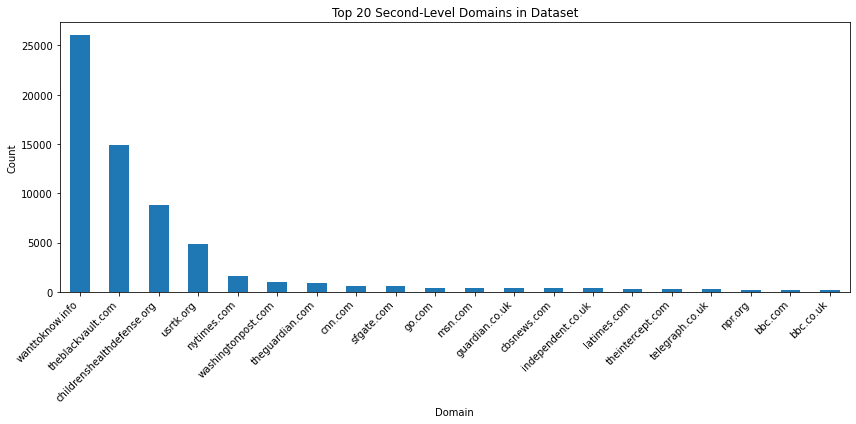

In [6]:
import matplotlib.pyplot as plt
import tldextract

# --- Extract registered domain (SLD + TLD) ---
def extract_domain(src: str) -> str:
    if not isinstance(src, str) or not src:
        return None
    ext = tldextract.extract(src)
    if ext.domain and ext.suffix:
        return f"{ext.domain}.{ext.suffix}".lower()
    return None

combined_df["Domain"] = combined_df["Source"].map(extract_domain)

# --- Count by domain ---
domain_counts = combined_df["Domain"].value_counts().head(20)  # top 20 for clarity

# --- Plot ---
plt.figure(figsize=(12,6))
domain_counts.plot(kind="bar")
plt.title("Top 20 Second-Level Domains in Dataset")
plt.xlabel("Domain")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [7]:
# Find rows where Domain could not be extracted
non_url_entries = combined_df[combined_df["Domain"].isna() | (combined_df["Domain"] == "")]

print(f"Found {len(non_url_entries)} entries where Source is not a URL.")

Found 17816 entries where Source is not a URL.


In [8]:
# make sense of trineday material

import pandas as pd
import re
import tldextract

# assume you have combined_df from earlier steps

def is_url_like(s: str) -> bool:
    if not isinstance(s, str) or not s.strip():
        return False
    ext = tldextract.extract(s)
    return bool(ext.suffix)  # has a public suffix => looks URL-like

ISBN_RE = re.compile(r"""
    (?<!\d)                     # not preceded by digit
    (?:97[89][-\s]?)?\d{1,5}[-\s]?\d{1,7}[-\s]?\d{1,7}[-\s]?[\dX]  # ISBN-10/13-ish
    (?!\d)                      # not followed by digit
""", re.VERBOSE | re.IGNORECASE)

def looks_like_isbn(s: str) -> bool:
    return bool(ISBN_RE.search(s or ""))

def looks_like_trineday_sitb(s: str) -> bool:
    return isinstance(s, str) and "_SITB" in s

def looks_like_title(s: str) -> bool:
    if not isinstance(s, str): return False
    if any(c in s for c in "/\\?.#@:"):  # URL-ish punctuation
        return False
    # Heuristic: titles have spaces and letters
    return any(ch.isalpha() for ch in s) and " " in s

candidates = combined_df["Source"].dropna().astype(str).unique().tolist()
bookish = [s for s in candidates
           if not is_url_like(s)
           and (looks_like_isbn(s) or looks_like_trineday_sitb(s) or looks_like_title(s))]

key_candidates_df = pd.DataFrame({"Source_original": sorted(set(bookish))})
OUT_LIST = r"C:/datasources/ai/trineday_source_candidates.csv"
key_candidates_df.to_csv(OUT_LIST, index=False, encoding="utf-8")
print(f"Wrote {len(key_candidates_df)} candidates to {OUT_LIST}")
key_candidates_df.head(10)


Wrote 36 candidates to C:/datasources/ai/trineday_source_candidates.csv


,Source_original
0,9781634240345_SITB
1,9781634241144_SITB
2,9781634241595_SITB
3,9781634241885
4,9781634242127
5,9781634242301
6,9781634242363
7,9781634242523
8,9781634242998
9,9781634243315


In [9]:
# Fix one specific Source string
combined_df["Source"] = combined_df["Source"].replace(
    "www.law.cornell.edu_uscode_text_18_1001",
    "https://www.law.cornell.edu/uscode/text/18/1001"
)

# Drop unwanted Sources
to_drop = [
    "WL0003SearchInside",
    "http://66.102.7.104/search?q=cache:SV_nwSXUZL0J:news.yahoo.com/s/nm/20051124/film_nm/arts_film_truce_dc"
]
before = len(combined_df)
combined_df = combined_df[~combined_df["Source"].isin(to_drop)].reset_index(drop=True)
after = len(combined_df)

print(f"Removed {before - after} rows. New total: {after}")


Removed 219 rows. New total: 86263


In [13]:
# crawl trineday to find titles

import pandas as pd
import re
import requests
from urllib.parse import quote
from bs4 import BeautifulSoup
from typing import Optional

# Input file of Source_original
sources_file = r"C:/datasources/ai/trineday_source_candidates.csv"
sources_df = pd.read_csv(sources_file)

BASE_SHOP = "https://trineday.myshopify.com"

def normalize_isbn(src: str) -> Optional[str]:
    """Strip _SITB and non-digits, return ISBN if length 10 or 13."""
    if not isinstance(src, str): 
        return None
    base = src.split("_SITB")[0]
    digits = re.sub(r"[^0-9Xx]", "", base)
    if len(digits) in (10, 13):
        return digits.upper()
    return None

def search_trineday(query: str) -> Optional[str]:
    """Return the first matching product URL from TrineDay search."""
    url = f"{BASE_SHOP}/search?q={quote(query)}"
    r = requests.get(url, timeout=20)
    r.raise_for_status()
    soup = BeautifulSoup(r.text, "html.parser")
    # Look for product links
    for a in soup.select('a[href*="/products/"]'):
        href = a.get("href", "")
        if "/products/" in href:
            return BASE_SHOP + href if href.startswith("/") else href
    return None

rows = []
for src in sources_df["Source_original"].astype(str):
    isbn = normalize_isbn(src)
    query = isbn if isbn else src
    try:
        url = search_trineday(query)
    except Exception as e:
        url = None
    rows.append({"Source_original": src, "Trineday_URL": url})

mapping_df = pd.DataFrame(rows)
out_path = r"C:/datasources/ai/trineday_source_mapping.csv"
mapping_df.to_csv(out_path, index=False, encoding="utf-8")
print(f"Mapping saved to {out_path}")
mapping_df.head(10)


Mapping saved to C:/datasources/ai/trineday_source_mapping.csv


,Source_original,Trineday_URL
0,9781634240345_SITB,https://trineday.myshopify.com/products/callin...
1,9781634241144_SITB,https://trineday.myshopify.com/products/being-...
2,9781634241595_SITB,https://trineday.myshopify.com/products/epidem...
3,9781634241885,None
4,9781634242127,None
5,9781634242301,None
6,9781634242363,None
7,9781634242523,None
8,9781634242998,None
9,9781634243315,None


In [14]:
import pandas as pd

# Paths
mapping_path = r"C:/datasources/ai/trineday_source_mapping.csv"

# Load your mapping file
mapping_df = pd.read_csv(mapping_path)

# Sanity check: should have Source_original and Trineday_URL columns
print(mapping_df.head())

# Merge with your combined_df
combined_df = combined_df.merge(
    mapping_df,
    left_on="Source",   # current values in your dataframe
    right_on="Source_original",
    how="left"
)

# Replace Source with the Trineday_URL if present
combined_df["Source"] = combined_df["Trineday_URL"].combine_first(combined_df["Source"])

# Drop helper columns if you don’t need them anymore
combined_df = combined_df.drop(columns=["Source_original", "Trineday_URL"])

# --- Clean up pipe characters in all string columns ---
for col in combined_df.columns:
    if combined_df[col].dtype == object:
        combined_df[col] = combined_df[col].astype(str).str.replace("|", "I", regex=False)

# --- Save as pipe-separated CSV ---
out_path = r"C:/datasources/ai/articles_plus_chunks_mapped.csv"
combined_df.to_csv(out_path, sep="|", index=False, encoding="utf-8")

print(f"Updated dataframe with mapped Sources saved to {out_path}")
print("Applied mapping. Sample rows:")
print(combined_df.head())


      Source_original                                       Trineday_URL
0  9781634240345_SITB  https://trineday.myshopify.com/products/callin...
1  9781634241144_SITB  https://trineday.myshopify.com/products/being-...
2  9781634241595_SITB  https://trineday.myshopify.com/products/epidem...
3       9781634241885                    https://trineday.myshopify.com/
4       9781634242127                    https://trineday.myshopify.com/
Updated dataframe with mapped Sources saved to C:/datasources/ai/articles_plus_chunks_mapped.csv
Applied mapping. Sample rows:
   ID                                              Title        Date  \
0   9  CNN Raises Serious Questions About 9/11 Over S...  2006-03-22   
1   2  Nationwide Child Abuse Ring In Free Discovery ...  2006-05-01   
2   3  Electronic voting switch threatens mass confusion  2006-05-01   
3   5  Fiscal Year 2005 U.S. Government Financial Sta...  2006-03-01   
4  10  Regaining My Humanity - A Career Soldier Choos...  2006-03-22   

  

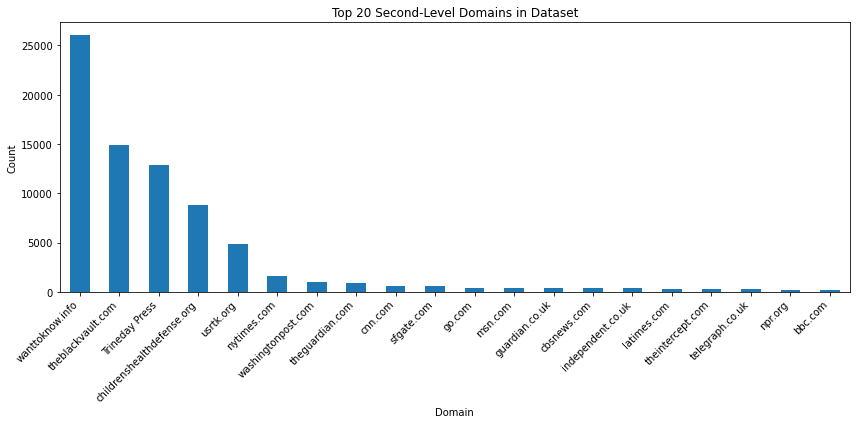

In [16]:
import matplotlib.pyplot as plt
import tldextract

# --- Extract registered domain (SLD + TLD) ---
def extract_domain(src: str) -> str:
    if not isinstance(src, str) or not src:
        return None
    ext = tldextract.extract(src)
    if ext.domain and ext.suffix:
        return f"{ext.domain}.{ext.suffix}".lower()
    return None

combined_df["Domain"] = combined_df["Source"].map(extract_domain)

# --- Count by domain ---
domain_counts = combined_df["Domain"].value_counts().head(20)  # top 20 for clarity

# Replace myshopify.com with "Trineday Press" in the counts index
domain_counts_renamed = domain_counts.rename(index={"myshopify.com": "Trineday Press"})

plt.figure(figsize=(12,6))
domain_counts_renamed.plot(kind="bar")
plt.title("Top 20 Second-Level Domains in Dataset")
plt.xlabel("Domain")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

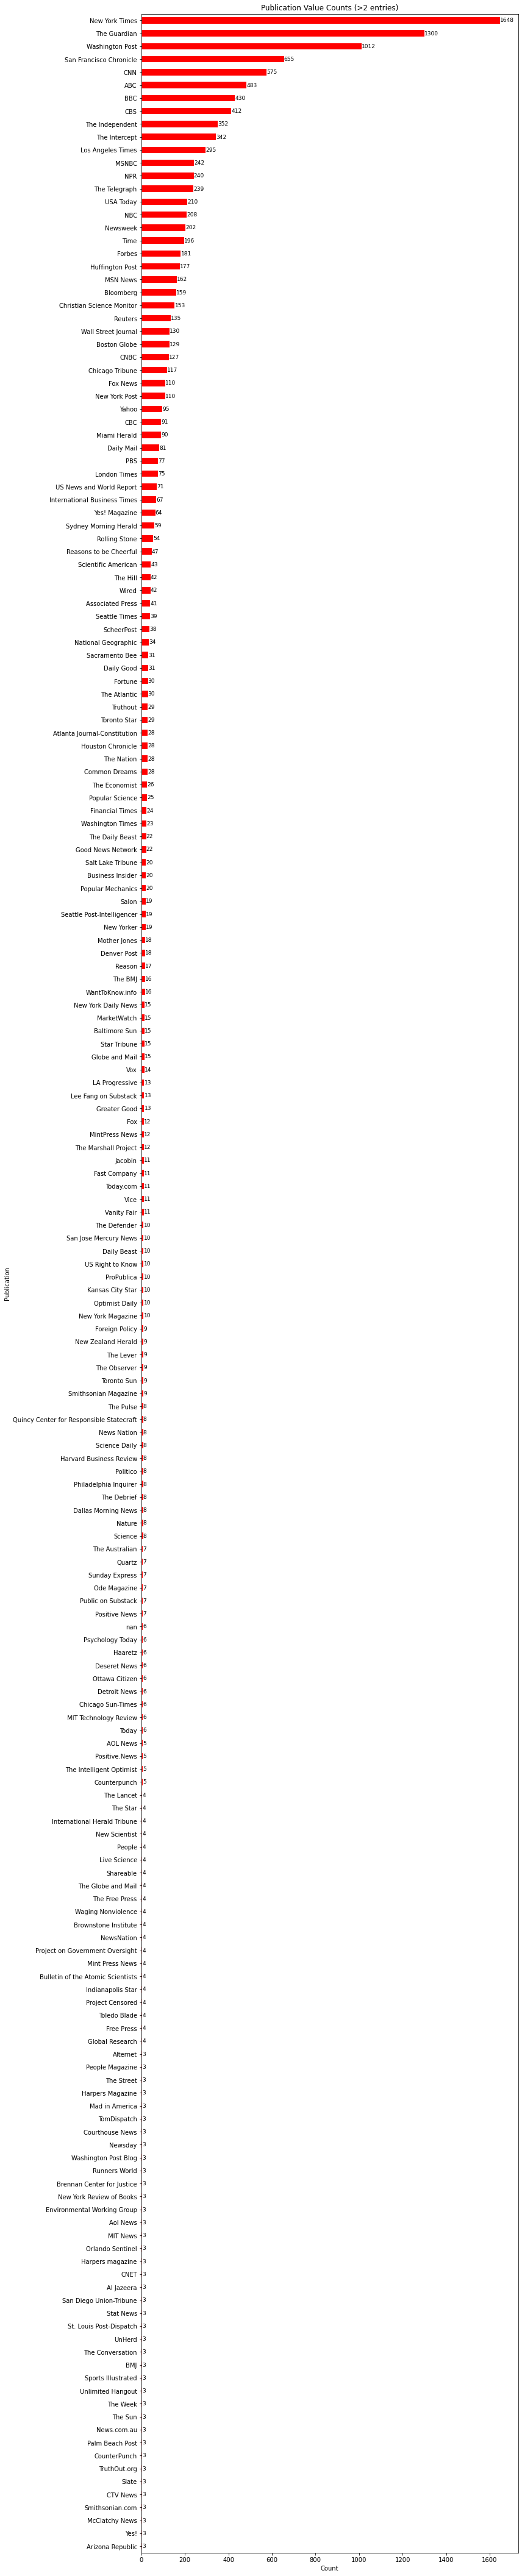

In [20]:
# Count publications, drop NaN, blanks, and literal "None"
pub_series = combined_df["Publication"].dropna().astype(str)
pub_series = pub_series[pub_series.str.strip().ne("")]
pub_series = pub_series[pub_series.str.strip().ne("None")]  # drop string "None"

pub_counts = pub_series.value_counts()

# Filter: keep only those with >2 occurrences
pub_counts = pub_counts[pub_counts > 2]

# Plot horizontal bar chart
plt.figure(figsize=(12, max(6, len(pub_counts) * 0.3)))
ax = pub_counts.plot(kind="barh", color="red")

plt.title("Publication Value Counts (>2 entries)")
plt.xlabel("Count")
plt.ylabel("Publication")
ax.invert_yaxis()  # largest on top

# Add labels at the end of bars
for count, y in zip(pub_counts.values, range(len(pub_counts))):
    ax.text(count + 0.5, y, str(count), va="center", ha="left", fontsize=9)

plt.tight_layout()
plt.show()

In [24]:
# --- Save as pipe-separated CSV ---
out_path = r"C:/datasources/ai/beta_slim_final.csv"
combined_df.to_csv(out_path, sep="|", index=False, encoding="utf-8")

In [3]:
# COMPLETE TF-IDF VECTORIZER BUILD (+ exports & query helper)

from pathlib import Path
import json, re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text as sklearn_text

# --- Config/paths ---
BASE = Path(r"C:/datasources/ai")
CSV_PATH = BASE / "beta_slim_final.csv"           # your combined dataset
TEXT_COL = "__text_for_tfidf__"
OUT_VOCAB = BASE / "betaslim/vocabulary.json"
OUT_IDF   = BASE / "betaslim/idf.json"
OUT_STOP  = BASE / "betaslim/stopwords.json"

# --- Load data ---
df = pd.read_csv(CSV_PATH, sep="|", encoding="utf-8")
assert TEXT_COL in df.columns, f"Missing column: {TEXT_COL}"

# --- Custom phrase removal (case-insensitive) ---
CUSTOM_PHRASES = [
    "Click here",
    "more along these lines",
    "About us",
]

# build one regex, ignore case
PHRASE_RE = re.compile("|".join(re.escape(p) for p in CUSTOM_PHRASES), flags=re.IGNORECASE)

CTRL_RE = re.compile(r"[\x00-\x08\x0b-\x1f\x7f]")  # non-printing control chars

def preprocessor(text: str) -> str:
    """Strip custom phrases & control chars, collapse whitespace."""
    s = "" if text is None else str(text)
    s = PHRASE_RE.sub(" ", s)      # remove custom phrases
    s = CTRL_RE.sub(" ", s)        # strip control chars
    s = re.sub(r"\s+", " ", s).strip()
    return s

# --- Stopword set (scikit-learn English) ---
EN_STOP = sorted(w.lower() for w in sklearn_text.ENGLISH_STOP_WORDS)  # <- list, not set

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=EN_STOP,        
    preprocessor=preprocessor,
    token_pattern=r"(?u)\b\w+\b",
    max_df=0.95,
    min_df=2,
    dtype=np.float32,
)

# --- Fit & transform ---
X = vectorizer.fit_transform(df[TEXT_COL].fillna(""))
N, V = X.shape
print(f"TF-IDF built: docs={N}, vocab={V}")

# --- Export artifacts for client parity ---

# 1) stopwords.json
with open(OUT_STOP, "w", encoding="utf-8") as f:
    json.dump(sorted(EN_STOP), f, ensure_ascii=False)
print("Wrote", OUT_STOP)

# 2) vocabulary.json (index -> token array)
# scikit stores token->index; invert it to a list ordered by index
tok2idx = vectorizer.vocabulary_
inv_vocab = [""] * len(tok2idx)
for tok, i in tok2idx.items():
    inv_vocab[i] = tok
with open(OUT_VOCAB, "w", encoding="utf-8") as f:
    json.dump(inv_vocab, f, ensure_ascii=False)
print("Wrote", OUT_VOCAB)

# 3) idf.json (aligned with vocabulary indices)
idf_vals = vectorizer.idf_.astype(np.float32)
# optional: round for smaller JSON
idf_out = [float(f"{v:.4f}") for v in idf_vals]
with open(OUT_IDF, "w", encoding="utf-8") as f:
    json.dump(idf_out, f, ensure_ascii=False)
print("Wrote", OUT_IDF)

# --- Helper: build a unit-norm TF-IDF vector for a query using the SAME pipeline ---
# Note: TfidfVectorizer handles analyzer steps internally; we replicate only what we need.

TOKEN_RE = re.compile(r"\b\w+\b", flags=re.UNICODE)

def _tokenize_like_vectorizer(s: str):
    # Apply SAME preprocessor first (phrase stripping, etc.)
    s = preprocessor(s).lower()
    # Tokenize
    toks = TOKEN_RE.findall(s)
    # Remove stopwords
    toks = [t for t in toks if t not in EN_STOP]
    return toks

def tfidf_query_vector(query: str) -> np.ndarray:
    """Return unit-norm TF-IDF vector aligned with vocabulary indices."""
    toks = _tokenize_like_vectorizer(query)
    if not toks:
        return np.zeros(len(inv_vocab), dtype=np.float32)
    # term frequency over known vocab
    tf = {}
    for t in toks:
        i = tok2idx.get(t)
        if i is not None:
            tf[i] = tf.get(i, 0) + 1
    if not tf:
        return np.zeros(len(inv_vocab), dtype=np.float32)
    # build dense vector and apply IDF (scikit's default normalization is L2 on TF-IDF)
    qv = np.zeros(len(inv_vocab), dtype=np.float32)
    for i, f in tf.items():
        qv[i] = f * idf_vals[i]
    # L2 normalize
    n = np.linalg.norm(qv) + 1e-12
    qv /= n
    return qv

# --- Quick sanity test ---
q = "Click here to learn more about us and cia covert operations"
qv = tfidf_query_vector(q)
print("Query vector shape:", qv.shape, "norm:", np.linalg.norm(qv))



TF-IDF built: docs=86263, vocab=154397
Wrote C:\datasources\ai\betaslim\stopwords.json
Wrote C:\datasources\ai\betaslim\vocabulary.json
Wrote C:\datasources\ai\betaslim\idf.json
Query vector shape: (154397,) norm: 0.99999994


In [7]:
import math
import numpy as np
from collections import deque
from sklearn.cluster import KMeans

# --------- CONFIG ---------
CAP = 1500           # max items per final group
MIN_SPLIT = 2        # minimum k when we split a cluster
MAX_SPLIT = 10       # don't split any single cluster into more than this many at once
RANDOM_STATE = 42
N_INIT = 10
MAX_ITER = 300

def _choose_split_k(n_items, cap=CAP, min_k=MIN_SPLIT, max_k=MAX_SPLIT):
    """
    For a cluster of size n_items, choose a k that should bring subclusters under 'cap' on average.
    We clamp k to [min_k, max_k].
    """
    k = int(math.ceil(n_items / cap))
    k = max(min_k, min(max_k, k))
    return k

def _kmeans_split(X_sub, k, random_state=RANDOM_STATE):
    """
    Run KMeans on the provided sub-matrix X_sub (rows = items in this cluster).
    Returns labels (len = X_sub.shape[0]) and the fitted model.
    """
    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=N_INIT,
        max_iter=MAX_ITER,
        random_state=random_state,
        verbose=0
    )
    labels = km.fit_predict(X_sub)
    return labels, km

def recursive_kmeans_cap(X, cap=CAP, random_state=RANDOM_STATE, verbose=True):
    """
    Recursively split clusters with KMeans until every cluster contains <= cap items.
    Returns:
      - groups: list of np.ndarray index arrays (global indices into X)
      - centroids: list of centroid vectors (np.ndarray), one per final group
    """
    N = X.shape[0]
    initial_indices = np.arange(N)
    queue = deque([initial_indices])
    final_groups = []

    while queue:
        idxs = queue.popleft()
        n = len(idxs)

        if n <= cap:
            # This group is small enough; accept as final
            final_groups.append(idxs)
            if verbose:
                print(f"✓ group accepted: size={n}")
            continue

        # Need to split
        k = _choose_split_k(n, cap=cap)
        if verbose:
            print(f"→ splitting group of size {n} with k={k}")

        # Slice X to the rows of this group
        X_sub = X[idxs]

        # Fit KMeans for this subset
        labels, km = _kmeans_split(X_sub, k, random_state=random_state)

        # Push each subcluster back to queue (by global indices)
        for c in range(k):
            sub_idxs = idxs[labels == c]
            if len(sub_idxs) == 0:
                continue
            queue.append(sub_idxs)

    # Compute centroids for the final groups (as mean TF-IDF vector per group)
    # If X is sparse, this stays efficient.
    centroids = []
    for gidxs in final_groups:
        Xg = X[gidxs]
        # centroid = mean along rows
        if hasattr(Xg, "mean"):  # works for numpy arrays and scipy sparse
            c = Xg.mean(axis=0)
            # bring to 1D np.array
            c = np.asarray(c).ravel()
        else:
            # Fallback (shouldn't happen): convert to dense
            c = np.mean(np.asarray(Xg), axis=0)
        # (Optional) L2-normalize centroid now if you'll use cosine
        norm = np.linalg.norm(c) + 1e-12
        centroids.append((c / norm).astype(np.float32))
    centroids = np.vstack(centroids).astype(np.float32)

    return final_groups, centroids

# ------------------ USAGE ------------------
# X is your TF-IDF matrix (dense or CSR sparse). N = X.shape[0].

groups, centroids_unit = recursive_kmeans_cap(X, cap=1500, random_state=RANDOM_STATE, verbose=True)
print(f"Final number of groups: {len(groups)}")
sizes = [len(g) for g in groups]
print(f"Min/Max group size: {min(sizes)} / {max(sizes)}")

# Build a labels array (cluster id per document) if you need it downstream
labels_balanced = np.empty(X.shape[0], dtype=np.int32)
for gid, gidxs in enumerate(groups):
    labels_balanced[gidxs] = gid

# 'centroids_unit' are L2-normalized centroids per final group (good for cosine).
# If you prefer unnormalized, just remove the normalization block above.

→ splitting group of size 86263 with k=10
✓ group accepted: size=732
✓ group accepted: size=773
→ splitting group of size 1520 with k=2
→ splitting group of size 4546 with k=4
→ splitting group of size 19511 with k=10
→ splitting group of size 31729 with k=10
→ splitting group of size 13923 with k=10
✓ group accepted: size=543
→ splitting group of size 4266 with k=3
→ splitting group of size 8720 with k=6
✓ group accepted: size=786
✓ group accepted: size=734
✓ group accepted: size=1281
→ splitting group of size 2866 with k=2
✓ group accepted: size=80
✓ group accepted: size=319
→ splitting group of size 2245 with k=2
→ splitting group of size 1553 with k=2
→ splitting group of size 3149 with k=3
→ splitting group of size 2908 with k=2
✓ group accepted: size=1388
✓ group accepted: size=468
→ splitting group of size 6308 with k=5
✓ group accepted: size=834
✓ group accepted: size=150
✓ group accepted: size=508
✓ group accepted: size=191
→ splitting group of size 1715 with k=2
✓ group accep

In [9]:
# Make the index shards (balanced groups version)

from pathlib import Path
import json, re, math
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.sparse import csr_matrix

# ---------- PATHS ----------
BASE      = Path(r"C:/datasources/ai")
CSV_PATH  = BASE / "beta_slim_final.csv"
TEXT_COL  = "__text_for_tfidf__"

# All artifacts go here:
OUT_DIR   = BASE / "betaslim"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Individual files
OUT_VOCAB = OUT_DIR / "vocabulary.json"
OUT_IDF   = OUT_DIR / "idf.json"
OUT_STOP  = OUT_DIR / "stopwords.json"     # (only if you also export stopwords)
OUT_CENTS = OUT_DIR / "centroids.json"
OUT_INDEX = OUT_DIR / "centroids_index.json"

# ---------- Helpers ----------
def float4(x: float) -> float:
    """Round to 4 decimals to shrink JSON size."""
    return float(f"{x:.4f}")

# ---------- 1) vocabulary.json (index -> token) ----------
tok2idx = vectorizer.vocabulary_                       # token -> index
inv_vocab = [""] * len(tok2idx)
for tok, idx in tok2idx.items():
    inv_vocab[idx] = tok
with open(OUT_VOCAB, "w", encoding="utf-8") as f:
    json.dump(inv_vocab, f, ensure_ascii=False)

# ---------- 2) idf.json (aligned with vocabulary indices) ----------
idf_arr = vectorizer.idf_.astype(np.float32)           # np.array shape (V,)
idf_out = [float4(v) for v in idf_arr.tolist()]
with open(OUT_IDF, "w", encoding="utf-8") as f:
    json.dump(idf_out, f, ensure_ascii=False)

# ---------- 3) centroids.json (already unit-norm from recursive_kmeans_cap) ----------
# centroids_unit: np.ndarray shape (K, V), L2-normalized
centroids_json = [[float4(v) for v in row] for row in centroids_unit]
with open(OUT_CENTS, "w", encoding="utf-8") as f:
    json.dump(centroids_json, f, ensure_ascii=False)

# ---------- 4) groups: one JSON per final cluster with sparse tf-idf + doc info ----------
# Ensure CSR for fast row ops
if not isinstance(X, csr_matrix):
    X = csr_matrix(X)

# Precompute L2 norms for cosine
doc_norms = np.sqrt((X.multiply(X)).sum(axis=1)).A1 + 1e-12  # shape (N,)

group_files = []
for g, idxs in tqdm(list(enumerate(groups)), desc="Writing groups"):
    Xg = X[idxs]  # CSR view

    rows = []
    for i_local, i_doc in enumerate(idxs):
        row = Xg.getrow(i_local)          # 1xV CSR
        cols = row.indices                # nonzero column indices
        data = row.data                   # corresponding tf-idf weights

        pairs = [[int(c), float4(w)] for c, w in zip(cols, data)]

        # prefer your dataset ID if present; else fallback to i_doc
        if "ID" in df.columns and pd.notna(df.iloc[i_doc].get("ID", np.nan)):
            row_id_val = int(df.iloc[i_doc]["ID"])
        else:
            row_id_val = int(i_doc)

        rows.append({
            "row_id": row_id_val,
            "source": df.iloc[i_doc].get("Source", None),
            "title":  df.iloc[i_doc].get("Title", None),
            "text":   df.iloc[i_doc].get(TEXT_COL, None),   # optional: remove to shrink shard
            "norm":   float4(doc_norms[i_doc]),
            "tfidf":  pairs
        })

    out_path = OUT_DIR / f"group_{g:03d}.json"
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(rows, f, ensure_ascii=False)
    group_files.append(out_path.name)   # store only filename in manifest

# ---------- 5) centroids_index.json (manifest) ----------
K = len(groups)
manifest = {"version": 1, "k": K, "groups": group_files}
with open(OUT_INDEX, "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False)

print("Exported to:", OUT_DIR)
print(" Files: vocabulary.json, idf.json, centroids.json, centroids_index.json, and group_XXX.json shards")

Writing groups: 100%|████████████████████████████████████████████████████████████████| 133/133 [01:38<00:00,  1.35it/s]

Exported to: C:\datasources\ai\betaslim
 Files: vocabulary.json, idf.json, centroids.json, centroids_index.json, and group_XXX.json shards


In [12]:
# === Local TF-IDF search test (no IPFS) ===
from pathlib import Path
import json, re
import numpy as np
import pandas as pd

# --- Paths ---
OUT_DIR   = Path(r"C:/datasources/ai/betaslim")
VOCAB_FN  = OUT_DIR / "vocabulary.json"
IDF_FN    = OUT_DIR / "idf.json"
CENTS_FN  = OUT_DIR / "centroids.json"
INDEX_FN  = OUT_DIR / "centroids_index.json"
STOP_FN   = OUT_DIR / "stopwords.json"    # if you exported it; else set to None

# --- Load artifacts ---
with open(VOCAB_FN, "r", encoding="utf-8") as f:
    vocab_list = json.load(f)                 # index -> token
token_to_idx = {t:i for i,t in enumerate(vocab_list)}
V = len(vocab_list)

with open(IDF_FN, "r", encoding="utf-8") as f:
    idf = np.array(json.load(f), dtype=np.float32)   # length V

with open(CENTS_FN, "r", encoding="utf-8") as f:
    C = np.array(json.load(f), dtype=np.float32)     # (K, V) already L2-normalized

with open(INDEX_FN, "r", encoding="utf-8") as f:
    manifest = json.load(f)                          # {"k":K, "groups":[... filenames ...]}

# Stopwords (optional but recommended for full parity)
try:
    with open(STOP_FN, "r", encoding="utf-8") as f:
        stopwords = set(json.load(f))
except FileNotFoundError:
    stopwords = set()  # fallback if you didn’t export

# --- Preprocessing: same phrase stripping as Python vectorizer ---
CUSTOM_PHRASES = [
    "Click here",
    "more along these lines",
    "About us",
]
PHRASE_RES = [re.compile(re.escape(p), flags=re.IGNORECASE) for p in CUSTOM_PHRASES]
TOKEN_RE = re.compile(r"\b\w+\b", flags=re.UNICODE)

def preprocess_text(s: str) -> str:
    if s is None:
        return ""
    t = str(s)
    for r in PHRASE_RES:
        t = r.sub(" ", t)
    t = re.sub(r"[\x00-\x08\x0b-\x1f\x7f]", " ", t)  # control chars
    t = re.sub(r"\s+", " ", t).strip().lower()
    return t

def tokenize(s: str):
    return TOKEN_RE.findall(preprocess_text(s))

# --- Build unit-norm TF-IDF for a query ---
def tfidf_query_vector(q: str) -> np.ndarray:
    toks = tokenize(q)
    if stopwords:
        toks = [t for t in toks if t not in stopwords]
    if not toks:
        return np.zeros(V, dtype=np.float32)
    tf = {}
    for t in toks:
        i = token_to_idx.get(t)
        if i is not None:
            tf[i] = tf.get(i, 0) + 1
    if not tf:
        return np.zeros(V, dtype=np.float32)
    qv = np.zeros(V, dtype=np.float32)
    for i, f in tf.items():
        qv[i] = f * idf[i]
    n = np.linalg.norm(qv) + 1e-12
    qv /= n
    return qv

# --- Centroid routing (cosine since both sides are L2-normalized) ---
def topk_centroids(qv: np.ndarray, k: int = 3):
    sims = C @ qv                      # (K,)
    idx = np.argsort(-sims)[:k]
    return [(int(i), float(sims[i])) for i in idx]

# --- Search inside specific groups (use local JSON shards) ---
def search_in_groups(qv: np.ndarray, group_ids, top_docs: int = 5):
    results = []
    for gid in group_ids:
        group_name = manifest["groups"][gid]     # e.g., 'group_012.json'
        with open(OUT_DIR / group_name, "r", encoding="utf-8") as f:
            rows = json.load(f)                  # each row has: tfidf [[idx, w]...], norm, title, source, text, row_id
        for r in rows:
            # sparse dot
            dot = 0.0
            for idx, w in r["tfidf"]:
                dot += w * qv[idx]
            sim = dot / (r["norm"])             # qv is unit-norm
            results.append((sim, gid, r))
    results.sort(key=lambda x: -x[0])
    return results[:top_docs]

# --- Convenience: end-to-end search ---
def search_json(query: str, k_centroids: int = 5, top_docs: int = 5):
    qv = tfidf_query_vector(query)
    if np.all(qv == 0):
        return "[]"
    centroids = topk_centroids(qv, k=k_centroids)
    gids = [cid for cid, _ in centroids]
    hits = search_in_groups(qv, gids, top_docs=top_docs)

    # Build list of {source, snippet}
    results = []
    for score, gid, r in hits:
        results.append({
            "source": r.get("source"),
            "snippet": (r.get("text") or "")[:240]
        })

    return json.dumps(results, indent=2, ensure_ascii=False)

# --- Example ---
print(search_json("cia covert operations in southeast asia and media propaganda"))


[
  {
    "source": "www.wanttoknow.info/mass/media/operation-mockingbird",
    "snippet": "in our world don t miss this masterful exposé And check out our What you can do section at the end of this article to take action and make a difference With best wishes for a transformed world Fred Burks for PEERS and WantToKnow info Former"
  },
  {
    "source": "https://trineday.myshopify.com/",
    "snippet": "in both American and foreign news organizations In some cases officials of these organizations were witting of these relationships in others not Some of the journalists did positive intelligence gathering for the CIA others merely exchanged"
  },
  {
    "source": "https://trineday.myshopify.com/products/americas-nazi-secret?_pos=1&_sid=785b9097c&_ss=r",
    "snippet": "some detail in J Loftus and M Aarons The Secret War Against the Jews 9 Under the Eisenhower administration the CIA OPC s covert activities expanded rapidly After the end of the Korean War in 1953 the perception of the S

In [18]:
# upload to ipfs

import os, json, time, hashlib, contextlib
from pathlib import Path
import requests

# --- CONFIG ---
FOLDER = Path(r"C:/datasources/ai/betaslim")
assert FOLDER.is_dir(), FOLDER

# 1) JWT (recommended)
PINATA_JWT = "your jwt"
HEADERS_AUTH = {"Authorization": f"Bearer {PINATA_JWT}"}

# 2) OR API key/secret:
# PINATA_API_KEY = "..."
# PINATA_API_SECRET = "..."
# HEADERS_AUTH = {"pinata_api_key": PINATA_API_KEY, "pinata_secret_api_key": PINATA_API_SECRET}

DEDICATED = "https://peers.mypinata.cloud/ipfs/"
CUSTOM    = "https://ai.peerservice.org/ipfs/"

# Optional: basic retry settings
MAX_RETRIES = 3
BACKOFF_SEC = 2.0

def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

def pin_one_file(path: Path, name_in_ipfs: str) -> str:
    """
    Pins a single file to IPFS via Pinata and returns the CID (IpfsHash).
    name_in_ipfs is used as the Pinata name/metadata only; it does NOT create folders.
    """
    url = "https://api.pinata.cloud/pinning/pinFileToIPFS"
    # Each request includes exactly one 'file' part -> avoids the "More than one file..." 400
    files = {
        "file": (name_in_ipfs, open(path, "rb"), "application/octet-stream")
    }
    data = {
        "pinataMetadata": json.dumps({"name": name_in_ipfs}),
        # No wrapWithDirectory here; pinning individual files
    }
    headers = {**HEADERS_AUTH}

    # Retry loop
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            resp = requests.post(url, headers=headers, files=files, data=data, timeout=600)
            if not resp.ok:
                # helpful error body
                print(f"[{name_in_ipfs}] Status:", resp.status_code, "Body:", resp.text)
                resp.raise_for_status()
            return resp.json()["IpfsHash"]
        except Exception as e:
            if attempt == MAX_RETRIES:
                raise
            time.sleep(BACKOFF_SEC * attempt)
        finally:
            with contextlib.suppress(Exception):
                files["file"][1].close()

# Build per-file manifest
entries = []
for root, _, files in os.walk(FOLDER):
    for fname in files:
        p = Path(root) / fname
        rel = p.relative_to(FOLDER).as_posix()

        cid = pin_one_file(p, name_in_ipfs=rel)
        entry = {
            "name": rel,
            "size": p.stat().st_size,
            "sha256": sha256_file(p),
            "cid": cid,
            "url_dedicated": DEDICATED + cid,
            "url_custom":    CUSTOM + cid
        }
        entries.append(entry)
        print(f"Pinned {rel} -> {cid}")

# Save the by-file manifest locally
manifest = {
    "version": 1,
    "pinned_at": int(time.time()),
    "files": sorted(entries, key=lambda x: x["name"]),
    "gateways": {"dedicated": DEDICATED, "custom": CUSTOM}
}
MANIFEST_PATH = FOLDER / "betaslim_manifest.byfile.json"
with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)
print("Wrote", MANIFEST_PATH)

# Convenience file: map group filename -> full custom-gateway URL by CID
groups_urls = {
    e["name"]: e["url_custom"]
    for e in entries
    if e["name"].startswith("group_") and e["name"].endswith(".json")
}
with open(FOLDER / "groups_urls.json", "w", encoding="utf-8") as f:
    json.dump(groups_urls, f, ensure_ascii=False, indent=2)
print("Wrote", FOLDER / "groups_urls.json")


Pinned centroids.json -> QmTU9f1i9fzLRewSc3jJEPQRKcNKeDv98GZKBzZVcKpam5
Pinned centroids_index.json -> QmTnEdEyGEtjUyHFM59BniaT61ug9kqQUR5Hw1ntk6oacx
Pinned group_000.json -> QmS2yjFP5Jy6KrQVykoJYv7Q4f4694s8tP9afEDp38D7vv
Pinned group_001.json -> Qmev8c556G28yEZLp5MX6E3hs8hzk9ec6Qu88sCN41pRgZ
Pinned group_002.json -> Qmd9FKoH1UmM8tS6fdY9bmjYcc5AMaBhZVBETxL5kUAxsj
Pinned group_003.json -> QmYGFVVYh4PEWwAhVr5K3a49fC73Gq8DNAkJHZmdwy8SPT
Pinned group_004.json -> QmSS28xr9DGh5r8F4FuxWYtBu2yqvqfykpsRSs15j82TTE
Pinned group_005.json -> QmZhAibNaCUuDuDq8FQwTSp2XbnuJU7KHAm6iooo1UZJRB
Pinned group_006.json -> QmaWcdeDZvFRdojn2g4KC6V6hs264su1MKkz4qQhmxMUJC
Pinned group_007.json -> QmPreXQdAsgniPUs8WaWAt7buvmp6sTZrxSSVNnkihGrCM
Pinned group_008.json -> QmNXJJXsc6Ug1mzUndCkddEm999C4M1BpJ7X2EYZ1ptAsC
Pinned group_009.json -> QmYbNPsAQH1mZUAF7AWPfquwTJTPrf2N8sFNnZXzi3NWHk
Pinned group_010.json -> QmbHppznzV7jmfn8qSQmXgXKkEMccwetcFsKKU6H7TbQzA
Pinned group_011.json -> QmWbebouspixSGwvcoSjNJVhZofcDqb94

Pinned group_112.json -> QmeqmMQScgfWUCNhvmmmgjbpFQMCiTNo43Z49fNb1zgUrH
Pinned group_113.json -> QmdELwN12dk3YSLUby5zuEBsqGyzVTZebi3DH9q146bbnL
Pinned group_114.json -> QmU4iitrFZC3PyE4B1nGtCSgnN72fE9BgaJMUkKeacB6Jq
Pinned group_115.json -> QmbkjEjSc6Yo95fhHaPNaSZzkjZ3MA9hR7zoZfxUbgU4mj
Pinned group_116.json -> QmPewcaVEkyS2bxxndC1RWh45HuJfbgPs7LmepQ6AC3d8P
Pinned group_117.json -> QmQawQtdNXcSzWEL782s5T582So57iFY6LQB1o1zCa7UWf
Pinned group_118.json -> QmatmxWEjcGgfsNxj9doSNgB5YDYL3eMSLGXAmMtu77PGm
Pinned group_119.json -> QmfHRbsY44LMmckbuVopsSCQSorGk9su4zNHpys3RZQVur
Pinned group_120.json -> QmdW3fAozUogsDQXyggHZXYkuMMAR9rgDzr25PWGW5xdAQ
Pinned group_121.json -> QmVNuopRFFbgMvHpz3AG8vCjZLymp33Cp2wXCfQfKvrAPk
Pinned group_122.json -> QmPWbK6ogf1ryBieXKen7x72xjWHem6K8KyCMSpxDoDZka
Pinned group_123.json -> QmcAadYhcYeSsHixMfmsYTLP9WEuRyZoJyHMpyyS2ugnXi
Pinned group_124.json -> QmZHVPRsK4KPhtHdNP23PrapmwBy9kzjBYgcPnXKKJ3Pbi
Pinned group_125.json -> QmNRXMKKRYRiZu5GHhCJe6jGGRNnuakN1iDDF1c

In [19]:
import json, contextlib
from pathlib import Path
import requests

# --- Config ---
FOLDER = Path(r"C:/datasources/ai/betaslim")
FILES_TO_PIN = [
    FOLDER / "betaslim_manifest.byfile.json",
    FOLDER / "groups_urls.json",
]

# Auth (choose one method)
PINATA_JWT = "your jwt"
HEADERS_AUTH = {"Authorization": f"Bearer {PINATA_JWT}"}

# OR if using API key/secret:
# HEADERS_AUTH = {"pinata_api_key": "...", "pinata_secret_api_key": "..."}

results = {}
for path in FILES_TO_PIN:
    files = {"file": (path.name, open(path, "rb"), "application/json")}
    try:
        resp = requests.post(
            "https://api.pinata.cloud/pinning/pinFileToIPFS",
            headers=HEADERS_AUTH,
            files=files,
            data={"pinataMetadata": json.dumps({"name": path.name})},
            timeout=600,
        )
        resp.raise_for_status()
        cid = resp.json()["IpfsHash"]
        results[path.name] = {
            "cid": cid,
            "url_dedicated": f"https://peers.mypinata.cloud/ipfs/{cid}",
            "url_custom":    f"https://ai.peerservice.org/ipfs/{cid}",
        }
        print(f"Pinned {path.name} -> {cid}")
    finally:
        with contextlib.suppress(Exception):
            files["file"][1].close()

print("\nSummary:")
print(json.dumps(results, indent=2))


Pinned betaslim_manifest.byfile.json -> QmVkr8cna15YPiskwuV3emrwAeYC99ALLuRbEjDZK28MnH
Pinned groups_urls.json -> QmczPZfPVTJbPmrxw8NBwNhdFNy9L7qwfMSaEu1zQvcPsY

Summary:
{
  "betaslim_manifest.byfile.json": {
    "cid": "QmVkr8cna15YPiskwuV3emrwAeYC99ALLuRbEjDZK28MnH",
    "url_dedicated": "https://peers.mypinata.cloud/ipfs/QmVkr8cna15YPiskwuV3emrwAeYC99ALLuRbEjDZK28MnH",
    "url_custom": "https://ai.peerservice.org/ipfs/QmVkr8cna15YPiskwuV3emrwAeYC99ALLuRbEjDZK28MnH"
  },
  "groups_urls.json": {
    "cid": "QmczPZfPVTJbPmrxw8NBwNhdFNy9L7qwfMSaEu1zQvcPsY",
    "url_dedicated": "https://peers.mypinata.cloud/ipfs/QmczPZfPVTJbPmrxw8NBwNhdFNy9L7qwfMSaEu1zQvcPsY",
    "url_custom": "https://ai.peerservice.org/ipfs/QmczPZfPVTJbPmrxw8NBwNhdFNy9L7qwfMSaEu1zQvcPsY"
  }
}


In [20]:
# store manifest and group urls on hive blockchain manually then test retrieve the data

import requests

RPC = "https://api.hive.blog"

def rpc(method, params):
    r = requests.post(RPC, json={"jsonrpc":"2.0","id":1,"method":method,"params":params})
    r.raise_for_status()
    data = r.json()
    if "error" in data:
        raise RuntimeError(data["error"])
    return data["result"]

author   = "wanttoknow"
permlink = "seeds-of-truth-index-registration-0-1"

c = rpc("condenser_api.get_content", [author, permlink])

print("Author:", c["author"])
print("Permlink:", c["permlink"])
print("Created (UTC):", c["created"])
print("Is root post?:", c["parent_author"] == "")

print("\n--- BODY ---\n")
print(c["body"])

Author: wanttoknow
Permlink: seeds-of-truth-index-registration-0-1
Created (UTC): 2025-09-12T21:34:45
Is root post?: True

--- BODY ---

```
{
  "betaslim_manifest.byfile.json": {
    "cid": "QmVkr8cna15YPiskwuV3emrwAeYC99ALLuRbEjDZK28MnH",
    "url_dedicated": "https://peers.mypinata.cloud/ipfs/QmVkr8cna15YPiskwuV3emrwAeYC99ALLuRbEjDZK28MnH",
    "url_custom": "https://ai.peerservice.org/ipfs/QmVkr8cna15YPiskwuV3emrwAeYC99ALLuRbEjDZK28MnH"
  },
  "groups_urls.json": {
    "cid": "QmczPZfPVTJbPmrxw8NBwNhdFNy9L7qwfMSaEu1zQvcPsY",
    "url_dedicated": "https://peers.mypinata.cloud/ipfs/QmczPZfPVTJbPmrxw8NBwNhdFNy9L7qwfMSaEu1zQvcPsY",
    "url_custom": "https://ai.peerservice.org/ipfs/QmczPZfPVTJbPmrxw8NBwNhdFNy9L7qwfMSaEu1zQvcPsY"
  }
}
```
